The config attributes {'feature_extractor': ['transformers', 'CLIPImageProcessor'], 'safety_checker': [None, None], 'text_encoder': [None, None], 'tokenizer': [None, None]} were passed to FlaxUnconditionalStableDiffusionPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'feature_extractor': ['transformers', 'CLIPImageProcessor'], 'safety_checker': [None, None], 'text_encoder': [None, None], 'tokenizer': [None, None]} are not expected by FlaxUnconditionalStableDiffusionPipeline and will be ignored.


Found 8 JAX devices of type TPU v3.


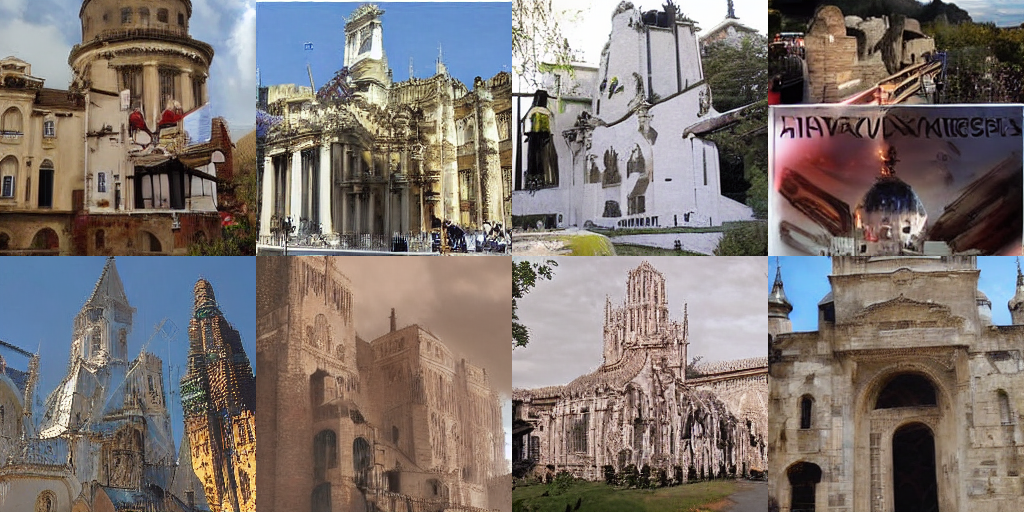

In [26]:
import numpy as np
import jax
import jax.numpy as jnp
from flax.jax_utils import replicate
from src.pipeline_flax_stable_diffusion import FlaxUnconditionalStableDiffusionPipeline, FlaxToyDiffusionPipeline
from PIL import Image
def load_model(path):
    num_devices = jax.device_count()
    device_type = jax.devices()[0].device_kind
    print(f"Found {num_devices} JAX devices of type {device_type}.")
    assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
    pipeline, params = FlaxUnconditionalStableDiffusionPipeline.from_pretrained(
        path,
    )
    params = replicate(params)
    return pipeline, params

def generate_unconditional(pipeline, params,H = 512):
    num_inference_steps = 50
    num_samples = jax.device_count()
    prng_seed = jax.random.PRNGKey(37)
    prng_seed = jax.random.split(prng_seed, num_samples)
    batch_size = 1
    images = pipeline(batch_size, params, prng_seed, num_inference_steps,height=H,width=H,jit=True).images
    images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_samples,) + images.shape[-3:])))
    grid_img = Image.new('RGB', (4*256, 2*256), color=(255,255,255))
    for index, image in enumerate(images):
        if index >= 8:
            break  # Stop if we have filled the grid
        row = index // 4
        col = index % 4
        x = col * 256
        y = row * 256
        grid_img.paste(image, (x, y))
    display(grid_img)
    return images

pipeline, params = load_model("sd-church-unconditional")
images = generate_unconditional(pipeline, params)

In [ ]:
def generate_toy(path):
    num_devices = jax.device_count()
    device_type = jax.devices()[0].device_kind
    print(f"Found {num_devices} JAX devices of type {device_type}.")
    assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
    pipeline, params = FlaxToyDiffusionPipeline.from_pretrained(path)
    params = replicate(params)
    num_inference_steps = 50
    prng_seed = jax.random.PRNGKey(23)
    prng_seed = jax.random.split(prng_seed, num_devices)
    batch_size = 1
    images = pipeline(batch_size, params, prng_seed, num_inference_steps,height=32,width=32,jit=True).images
    images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_devices*batch_size,) + images.shape[-3:])))
    for image in images:
        display(image)
    grid_img = Image.new('RGB', (4*256, 2*256), color=(255,255,255))
    for index, image in enumerate(images):
        if index >= 8:
            break  # Stop if we have filled the grid
        row = index // 4
        col = index % 4
        x = col * 256
        y = row * 256
        grid_img.paste(image, (x, y))
    display(grid_img)
    return images

images = generate_toy("sd-mnist")

In [40]:
import transformers
transformers.set_seed

<function transformers.trainer_utils.set_seed(seed: int)>

In [32]:

import jax
import jax.numpy as jnp
import flax.linen as nn
class PseudoConv(nn.Module):
    features: int = 320
    num_groups: int =32
    def setup(self):
        self.group_size = self.features // self.num_groups
        self.convg = nn.Conv(10, (3,3,3))
        self.convs = nn.Conv(32, (3,3,3))
    def __call__(self,x):
        x_old_shape = x.shape # NHwC
        x_shape_s = x.shape[:-1] + (self.num_groups, self.group_size)
        x = x.reshape(x_shape_s) # NHwGS
        x = jnp.moveaxis(x,-2,-4) # NGHWS
        x = self.convg(x)
        x = x.swapaxes(-4,-1) # NSHWG
        x = self.convs(x)
        x = jnp.moveaxis(x,-4,-1) # NGHWS
        return x.reshape(x_old_shape)

conv = PseudoConv()
out, params = conv.init_with_output(jax.random.PRNGKey(0), jnp.ones((1,256,256,320)))
out.shape, params.keys()

((1, 256, 256, 320), dict_keys(['params']))

In [ ]:
# Examples with diffusers package

# Text-to-Image
# num_devices = jax.device_count()
# device_type = jax.devices()[0].device_kind
# print(f"Found {num_devices} JAX devices of type {device_type}.")
# assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
# dtype = jnp.bfloat16
# pipeline, params = FlaxStableDiffusionPipeline.from_pretrained(
#     # "duongna/stable-diffusion-v1-4-flax",
#     "./sd-pokemon-unconditional",
#     # "./sd-pokemon-retry/",
#     # tokenizer=None,
#     # text_encoder=None,
#     # revision="bf16",
#     dtype=dtype,
# )
# num_inference_steps = 50
# num_samples = jax.device_count()
# params = replicate(params)
# pipeline.safety_checker=None


## torch-XLA is slow
# from diffusers import DiffusionPipeline
# import torch
# import torch_xla.core.xla_model as xm

# model_id = "stabilityai/stable-diffusion-xl-base-1.0"
# pipe = DiffusionPipeline.from_pretrained(model_id)

# device = xm.xla_device()
# pipe.to(device)

# prompt = "A pokemon with green eyes and red legs."
# start = time()
# image = pipe(prompt, num_inference_steps=inference_steps).images[0]
# print(f'Compilation time is {time()-start} sec')
# image.save("pokemon.png")

# start = time()
# image = pipe(prompt, num_inference_steps=inference_steps).images[0]
# print(f'Inference time is {time()-start} sec after compilation')


## 1-Step Distilled Model
# from diffusers import AutoPipelineForText2Image
# import torch

# pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=torch.float16, variant="fp16")

# prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."
# image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]

In [ ]:
# Audio, for teticio/audio-diffusion-512
from PIL import Image
image = Image.open("audio.jpg").convert("L")
images = [image]
import diffusers
mel = diffusers.Mel()
from IPython.display import Audio

audios = [Audio(mel.image_to_audio(image=image),rate=mel.get_sample_rate()) for image in images]

# audio = Audio(audio,rate=mel.get_sample_rate())
with open('audio.wav', 'wb') as f:
    f.write(audios[0].data)

In [ ]:
# conic activation
import jax
import jax.numpy as jnp
from functools import partial
import flax.linen as nn

# # prototype: split the first dimension as the Tai-Chi dimension
# @partial(jax.jit, static_argnames=['channel_axis','variant','eps'],)
# def colu(x, channel_axis = -3, variant = "soft", half_axis = False, eps = 1e-7):
#     if channel_axis == -3: # NCHW
#         x1, x_1 = x[...,:1,:,:], x[...,1:,:,:]
#     elif channel_axis == -1: # NC
#         x1, x_1 = x[...,:1], x[...,1:]
#     else:
#         raise NotImplementedError("channel_axis must be -1 or -3.")
    
#     x_1n = jnp.linalg.norm(x_1,axis=channel_axis,keepdims=True) # per-token norm
#     mask = x1 / (x_1n + eps)
#     print(x_1n)

#     if variant == "soft": # soft project
#         scaled_mask = nn.sigmoid(mask)
#     elif variant == "hard": # hard project
#         scaled_mask = mask > 0
#     else:
#         raise NotImplementedError("variant must be soft or hard.")

#     if half_axis: # single-sided cone
#         x1 = nn.relu(x1)

#     return jnp.concatenate([x1,scaled_mask*x_1],axis=channel_axis)

# x = jnp.zeros((1,3,1,2)) # two 3D tokens
# x = x.at[0,0,0,0].set(-10)
# x = x.at[0,1,0,0].set(-1)
# x = x.at[0,0,0,1].set(10)
# x = x.at[0,1,0,1].set(2)
# # x = [(-10,-1,0) (10,1,0)]
# print(colu(x, variant = "soft"))
# print(colu(x, variant = "hard", half_axis=True))

# The Ba-Gua idea: multi-cone topology, feeding input y as the axes. CF: adaptive group normalization (trivial-case reduction)
@partial(jax.jit, static_argnames=['channel_axis','variant','eps'],)
def group_colu(x, channel_axis = -3, variant = "soft", eps = 1e-7):
    num_channels = x.shape[channel_axis]
    y, x = x.take(jnp.arange(32), axis=channel_axis), x.take(jnp.arange(32,num_channels), axis=channel_axis)
    num_channels = x.shape[channel_axis]
    num_groups = y.shape[channel_axis] # number of cones
    assert num_channels % num_groups == 0, "Input must be a multiple of number of cones"
    group_size = num_channels // num_groups # S = C / G

    assert channel_axis < 0, "channel_axis must be negative" # Comply with broadcasting on first dimensions

    x_old_shape = x.shape
    y_old_shape = y.shape
    x_shape = x.shape[:channel_axis] + (num_groups, group_size)
    y_shape = y.shape[:channel_axis] + (num_groups, 1)
    if channel_axis < -1:
        x_shape += x.shape[(channel_axis+1):] # NGSHW if channel_axis = -3
        y_shape += y.shape[(channel_axis+1):] # NG1HW
    x = x.reshape(x_shape)
    y = y.reshape(y_shape)

    xn = jnp.linalg.norm(x,axis=channel_axis,keepdims=True) # NG1HW, per-group norm, or the S dimension

    mask = y / (xn + eps) # NG1HW

    if variant == "soft": # soft project
        scaled_mask = nn.sigmoid(mask-.5)
    elif variant == "hard": # hard project
        scaled_mask = mask.clip(0,1)
    else:
        raise NotImplementedError("variant must be soft or hard.")

    x = scaled_mask * x # NGSHW

    x = x.reshape(x_old_shape)
    y = y.reshape(y_old_shape)

    return jnp.concatenate([y,x],axis=channel_axis)

x = jnp.zeros((1,320)) # comply with GroupNorm(32)
# y = jnp.ones((1,32,1,2))
x = x.at[0,0,].set(1)
# [y x] = (-10,0,0,...)
x1 = group_colu(x, variant="soft",channel_axis=-1)
print(x1.shape)
# x1[0,:3,0,0]

In [ ]:
# Utility to list Parameters
def printTree(tree, d = 0):
    if (tree == None or len(tree) == 0):
        print("\t" * d, "-")
    else:
        for key, val in tree.items():
            if (isinstance(val, dict)):
                print("\t" * d, key)
                printTree(val, d+1)
            elif isinstance(val, jax.Array):
                print("\t" * d,key, val.shape)

printTree(params)

 unet
	 conv_in
		 bias (8, 320)
		 kernel (8, 3, 3, 4, 320)
	 conv_norm_out
		 bias (8, 320)
		 scale (8, 320)
	 conv_out
		 bias (8, 4)
		 kernel (8, 3, 3, 320, 4)
	 down_blocks_0
		 attentions_0
			 norm
				 bias (8, 320)
				 scale (8, 320)
			 proj_in
				 bias (8, 320)
				 kernel (8, 1, 1, 320, 320)
			 proj_out
				 bias (8, 320)
				 kernel (8, 1, 1, 320, 320)
			 transformer_blocks_0
				 attn1
					 to_k
						 kernel (8, 320, 320)
					 to_out_0
						 bias (8, 320)
						 kernel (8, 320, 320)
					 to_q
						 kernel (8, 320, 320)
					 to_v
						 kernel (8, 320, 320)
				 attn2
					 to_k
						 kernel (8, 320, 320)
					 to_out_0
						 bias (8, 320)
						 kernel (8, 320, 320)
					 to_q
						 kernel (8, 320, 320)
					 to_v
						 kernel (8, 320, 320)
				 ff
					 net_0
						 proj
							 bias (8, 2560)
							 kernel (8, 320, 2560)
					 net_2
						 bias (8, 320)
						 kernel (8, 1280, 320)
				 norm1
					 bias (8, 320)
					 scale (8, 320)
				 norm2
					 bi